# Historical-storm recovery pipeline + Huang (2025) validation

Runs the same probabilistic pipeline on 10 target historical storms, sets each  
storm's frequency = 1, and evaluates county-level recovery-potential against  
the Huang et al. (2025) observed-recovery dataset.

**Steps**
1. Inspect historical wind fields, map to ATCF IDs, identify missing storms  
2. Build CLIMADA Hazard (`frequency = 1`) from per-storm historical wind fields  
3. Derive historical Scaling NPZ from Dmat (W from hazard, R/S from Dmat)  
4. Impact: loop over coastal states, apply historical scaling  
5. Recovery potential via pyrecodes-light  
6. Huang validation (Spearman rank correlation, scatter/rank plots)  

In [1]:
from __future__ import annotations

import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy.stats import spearmanr

# -- repo root: works whether the kernel CWD is notebooks/ or the repo root --
_cwd = Path('.').resolve()
if (_cwd / 'data').exists():
    REPO = _cwd               # already at repo root
else:
    REPO = _cwd.parent        # one level up (typical when run from notebooks/)
    if not (REPO / 'data').exists():
        raise RuntimeError(f"Cannot locate repo root from {_cwd}")

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.chdir(REPO)   # ensure relative paths in impfunc_utils work

from modules.hazard_utils import load_tc_hazard_from_blended_mats
from modules.scaling_utils import (
    aggregate_hazard_to_counties,
    build_RS_from_dmat,
    build_historical_scaling_npz,
)
from modules.impfunc_utils import IMPF_SET_TC_CAPRA, DICT_PAGER_TCIMPF_CAPRA
from modules.impact_utils import export_state_and_county_results_all_events

from climada.hazard import Hazard
from climada.entity.exposures import Exposures
from climada.engine import ImpactCalc

warnings.filterwarnings('ignore', category=UserWarning)

print(f'REPO = {REPO}')
print('All imports OK')

REPO = /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential
All imports OK


## Paths and target storms

In [2]:
# ---- CLIMADA system directory ----
CLIMADA_DATA = Path('/Users/simonameiler/climada/data')

# ---- Historical input files ----
HIST_ROOT  = CLIMADA_DATA / 'hazard' / 'tropical_cyclone' / 'gori' / 'historical'
BLENDED_DIR = HIST_ROOT   # per-storm ATCF-named .mat files sit directly here
TRACK_MAT  = HIST_ROOT / 'Besttrack_GOM_1940_TS_trk100_corrected2.mat'

# ---- Exposure directory (per-state HDF5) ----
EXP_DIR = CLIMADA_DATA / 'exposure' / 'states'

# ---- Repo data files ----
DATA_DIR          = REPO / 'data'
COUNTY_REGION_CSV = DATA_DIR / 'county_region.csv'
COUNTIES_SHP      = DATA_DIR / 'US_counties.shp'
DMAT_CSV          = DATA_DIR / 'Dmat_region_all.csv'
HUANG_CSV         = DATA_DIR / 'huang_recovery_by_county_event.csv'
PERMITS_CSV       = DATA_DIR / 'selected_states_counties_with_permits.csv'

# ---- Output paths ----
HAZ_HDF5          = DATA_DIR / 'hazard' / 'gori_historical.hdf5'
SCALING_NPZ_HIST  = DATA_DIR / 'scaling_relative_historical.npz'
IMPACT_DIR_HIST   = DATA_DIR / 'impact_historical'
RECOVERY_DIR_HIST = DATA_DIR / 'recovery_historical'
FIGURES_DIR       = REPO / 'figures'

for d in [HAZ_HDF5.parent, IMPACT_DIR_HIST, RECOVERY_DIR_HIST, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- Target storms ----
TARGET_STORMS = [
    dict(atcf='AL142018', name='Michael',  year=2018, role='comparison'),
    dict(atcf='AL132020', name='Laura',    year=2020, role='comparison'),
    dict(atcf='AL092017', name='Harvey',   year=2017, role='comparison'),
    dict(atcf='AL112017', name='Irma',     year=2017, role='comparison'),
    dict(atcf='AL092012', name='Isaac',    year=2012, role='comparison'),
    dict(atcf='AL092016', name='Hermine',  year=2016, role='comparison'),
    dict(atcf='AL162017', name='Nate',     year=2017, role='comparison'),   # may be missing
    dict(atcf='AL122005', name='Katrina',  year=2005, role='illustration'), # not in Huang
    dict(atcf='AL092021', name='Ida',      year=2021, role='illustration'), # post-Dmat, wind-only
    dict(atcf='AL092022', name='Ian',      year=2022, role='illustration'), # post-Dmat, wind-only
]

# Storms without Dmat rain/surge coverage (set Scaling = 1)
WIND_ONLY_ATCF = ['AL092021', 'AL092022']   # Ida and Ian (Dmat ends 2020)

# Storms in Huang dataset used for evaluation
# Nate (AL162017) excluded: missing from historical wind field set
HUANG_ATCF_IDS = [
    'AL142018', 'AL132020', 'AL092017', 'AL112017',
    'AL092012', 'AL092016',
]

TARGET_ATCF = [s['atcf'] for s in TARGET_STORMS]
STORM_YEARS = {s['atcf']: s['year'] for s in TARGET_STORMS}
STORM_LABEL = {s['atcf']: f"{s['name']} ({s['year']})" for s in TARGET_STORMS}

print(f'Target ATCF IDs: {TARGET_ATCF}')
print(f'Wind-only (no Dmat): {WIND_ONLY_ATCF}')
print(f'Huang comparison: {HUANG_ATCF_IDS}')

Target ATCF IDs: ['AL142018', 'AL132020', 'AL092017', 'AL112017', 'AL092012', 'AL092016', 'AL162017', 'AL122005', 'AL092021', 'AL092022']
Wind-only (no Dmat): ['AL092021', 'AL092022']
Huang comparison: ['AL142018', 'AL132020', 'AL092017', 'AL112017', 'AL092012', 'AL092016']


## Step 1 — Inspect historical wind fields and identify missing storms

In [3]:
available_mats = {fp.stem for fp in BLENDED_DIR.glob('*.mat') if fp.stem != TRACK_MAT.stem}
print(f'Historical wind field .mat files found: {len(available_mats)}')
print(sorted(available_mats))

print()
PRESENT_ATCF = [a for a in TARGET_ATCF if a in available_mats]
MISSING_ATCF = [a for a in TARGET_ATCF if a not in available_mats]

for s in TARGET_STORMS:
    status = '✓' if s['atcf'] in available_mats else '✗ MISSING'
    print(f"  {s['atcf']}  {s['name']:<10} {s['year']}  {status}")

print(f'\nStorms PRESENT ({len(PRESENT_ATCF)}): {PRESENT_ATCF}')
print(f'Storms MISSING ({len(MISSING_ATCF)}): {MISSING_ATCF}')

Historical wind field .mat files found: 21
['AL011945', 'AL011953', 'AL011966', 'AL011968', 'AL011994', 'AL012001', 'AL021972', 'AL031947', 'AL031987', 'AL041985', 'AL092004', 'AL092012', 'AL092016', 'AL092017', 'AL092021', 'AL092022', 'AL102023', 'AL112017', 'AL122005', 'AL132020', 'AL142018']

  AL142018  Michael    2018  ✓
  AL132020  Laura      2020  ✓
  AL092017  Harvey     2017  ✓
  AL112017  Irma       2017  ✓
  AL092012  Isaac      2012  ✓
  AL092016  Hermine    2016  ✓
  AL162017  Nate       2017  ✗ MISSING
  AL122005  Katrina    2005  ✓
  AL092021  Ida        2021  ✓
  AL092022  Ian        2022  ✓

Storms PRESENT (9): ['AL142018', 'AL132020', 'AL092017', 'AL112017', 'AL092012', 'AL092016', 'AL122005', 'AL092021', 'AL092022']
Storms MISSING (1): ['AL162017']


## Step 2 — Build CLIMADA Hazard from historical wind fields

In [4]:
if HAZ_HDF5.exists():
    print(f'Loading cached hazard from {HAZ_HDF5}')
    haz_hist = Hazard.from_hdf5(str(HAZ_HDF5))
    missing_blended = MISSING_ATCF   # already computed above
    loaded_atcf = [n for n in haz_hist.event_name]
else:
    print('Building hazard from historical wind fields ...')
    haz_hist, missing_blended = load_tc_hazard_from_blended_mats(
        blended_dir     = BLENDED_DIR,
        track_mat_path  = TRACK_MAT,
        atcf_ids        = TARGET_ATCF,
        resolution_deg  = 0.25,   # must match probabilistic hazard
        pad_deg         = 1.0,
    )
    haz_hist.write_hdf5(str(HAZ_HDF5))
    print(f'Saved hazard → {HAZ_HDF5}')
    loaded_atcf = list(haz_hist.event_name)

print(f'Hazard events loaded  : {len(haz_hist.event_name)}')
print(f'Events               : {list(haz_hist.event_name)}')
print(f'Centroids            : {haz_hist.centroids.size:,}')
print(f'Frequency (all 1?)   : {np.unique(haz_hist.frequency)}')
print(f'Missing wind fields  : {missing_blended}')

Loading cached hazard from /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/data/hazard/gori_historical.hdf5
Hazard events loaded  : 9
Events               : ['AL142018', 'AL132020', 'AL092017', 'AL112017', 'AL092012', 'AL092016', 'AL122005', 'AL092021', 'AL092022']
Centroids            : 39,960
Frequency (all 1?)   : [1.]
Missing wind fields  : ['AL162017']


Saved footprint figure → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_footprints.png


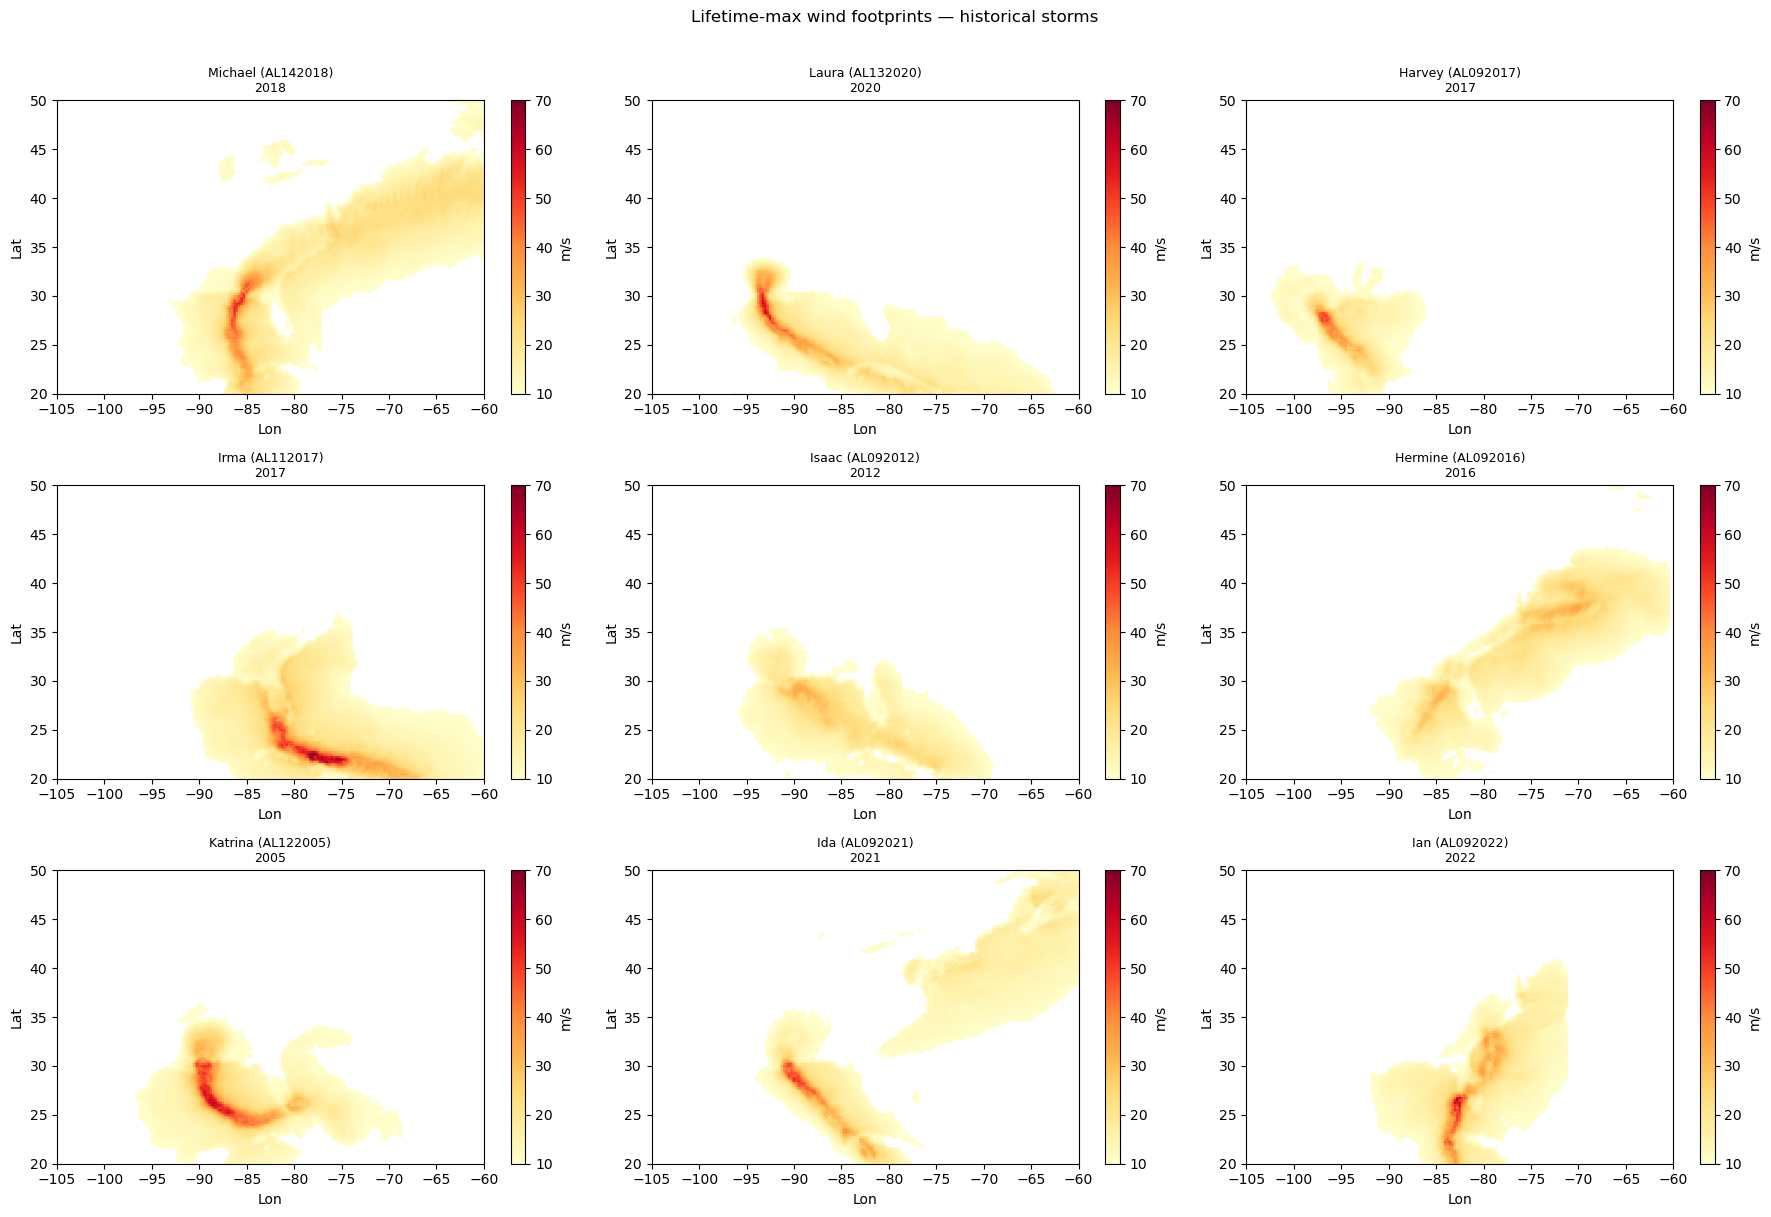

In [5]:
# ---- Quick footprint plots ----
loaded_atcf = list(haz_hist.event_name)
n_ev        = len(loaded_atcf)
ncols       = min(3, n_ev)
nrows       = (n_ev + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.atleast_1d(axes).ravel()

lons = haz_hist.centroids.lon
lats = haz_hist.centroids.lat

for idx, atcf_id in enumerate(loaded_atcf):
    ax    = axes[idx]
    row   = haz_hist.intensity[idx, :].toarray().ravel()
    mask  = row > 10.0  # plot wind > 10 m/s
    storm = next((s for s in TARGET_STORMS if s['atcf'] == atcf_id), {})
    sc = ax.scatter(lons[mask], lats[mask], c=row[mask], s=2,
                    cmap='YlOrRd', vmin=10, vmax=70, rasterized=True)
    plt.colorbar(sc, ax=ax, label='m/s')
    ax.set_title(f"{storm.get('name', atcf_id)} ({atcf_id})\n"
                 f"{storm.get('year','')}", fontsize=9)
    ax.set_xlim(-105, -60); ax.set_ylim(20, 50)
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')

for ax in axes[n_ev:]:
    ax.set_visible(False)

plt.suptitle('Lifetime-max wind footprints — historical storms', fontsize=12, y=1.01)
plt.tight_layout()
out_fp = FIGURES_DIR / 'hist_footprints.png'
plt.savefig(out_fp, dpi=150, bbox_inches='tight')
print(f'Saved footprint figure → {out_fp}')
plt.show()

## Step 3 — Historical scaling NPZ  
Build W (from hazard), R and S (from Dmat), compute Scaling via the same  
relative-contribution formulation as the probabilistic pipeline.  
Ida (2021) and Ian (2022) are forced to Scaling = 1 (wind-only, no Dmat).

In [6]:
county_region_df = pd.read_csv(COUNTY_REGION_CSV)
# rename region_str → region if needed by compute_scaling_relative
if 'region' not in county_region_df.columns and 'region_str' in county_region_df.columns:
    county_region_df = county_region_df.rename(columns={'region_str': 'region'})
print(f'Counties: {len(county_region_df)}  |  sample: {county_region_df.head(2).to_dict("records")}')

dmat_df = pd.read_csv(DMAT_CSV)
print(f'Dmat rows: {len(dmat_df)}  |  years: {dmat_df["year"].min()}–{dmat_df["year"].max()}')

# The hazard event_name list may be shorter than TARGET_ATCF if storms were missing
haz_atcf_ids = list(haz_hist.event_name)
haz_years    = [STORM_YEARS[a] for a in haz_atcf_ids]

# Which of the loaded storms are wind-only?
hist_wind_only = [a for a in haz_atcf_ids if a in WIND_ONLY_ATCF]
print(f'\nLoaded events: {haz_atcf_ids}')
print(f'Wind-only (Scaling=1): {hist_wind_only}')

Counties: 3220  |  sample: [{'county_index': 0, 'fips': 48061, 'stcode': 48, 'ccode': 61, 'region_num': 1.0, 'region': 'GOM', 'fill_source': 'county_mode'}, {'county_index': 1, 'fips': 48489, 'stcode': 48, 'ccode': 489, 'region_num': 1.0, 'region': 'GOM', 'fill_source': 'county_mode'}]
Dmat rows: 5595  |  years: 1996–2020

Loaded events: ['AL142018', 'AL132020', 'AL092017', 'AL112017', 'AL092012', 'AL092016', 'AL122005', 'AL092021', 'AL092022']
Wind-only (Scaling=1): ['AL092021', 'AL092022']


In [7]:
if SCALING_NPZ_HIST.exists():
    print(f'Loading cached historical scaling NPZ from {SCALING_NPZ_HIST}')
    _d = np.load(SCALING_NPZ_HIST, allow_pickle=True)
    print(f'  Keys: {_d.files}')
    print(f'  Scaling shape: {_d["Scaling"].shape}')
    print(f'  event_names: {list(_d["event_names"])}')
    print(f'  wind_only_flags: {_d["wind_only_flags"]}')
    # Still need W, R, S and match_report for inspection — rebuild from scratch
    W_hist = aggregate_hazard_to_counties(haz_hist, county_region_df, COUNTIES_SHP)
    R_hist, S_hist, match_report = build_RS_from_dmat(
        W_hist, haz_atcf_ids, haz_years, county_region_df, dmat_df,
        wind_only_atcf_ids=hist_wind_only,
    )
else:
    W_hist, R_hist, S_hist, match_report = build_historical_scaling_npz(
        haz               = haz_hist,
        event_atcf_ids    = haz_atcf_ids,
        event_years       = haz_years,
        county_region_df  = county_region_df,
        dmat_df           = dmat_df,
        counties_shp_path = COUNTIES_SHP,
        out_path          = SCALING_NPZ_HIST,
        wind_only_atcf_ids= hist_wind_only,
    )

print(f'\nW_hist  : {W_hist.shape}  non-zero={int((W_hist > 0).sum())}')
print(f'R_hist  : {R_hist.shape}  non-zero={int((R_hist > 0).sum())}')
print(f'S_hist  : {S_hist.shape}  non-zero={int((S_hist > 0).sum())}')

Loading cached historical scaling NPZ from /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/data/scaling_relative_historical.npz
  Keys: ['Scaling', 'is_coastal', 'county_index', 'event_names', 'wind_only_flags']
  Scaling shape: (9, 3220)
  event_names: ['AL142018', 'AL132020', 'AL092017', 'AL112017', 'AL092012', 'AL092016', 'AL122005', 'AL092021', 'AL092022']
  wind_only_flags: [0 0 0 0 0 0 0 1 1]
  [aggregate_hazard_to_counties] 8802/39960 centroids mapped to 2687 counties

W_hist  : (9, 3220)  non-zero=13062
R_hist  : (9, 3220)  non-zero=1169
S_hist  : (9, 3220)  non-zero=389


In [8]:
# ---- Inspect match report ----
print(f'Dmat match records: {len(match_report)}')
if not match_report.empty:
    print(f'  Residual (m/s) — mean: {match_report["residual"].mean():.2f},  '
          f'p50: {match_report["residual"].median():.2f},  '
          f'p95: {match_report["residual"].quantile(0.95):.2f},  '
          f'max: {match_report["residual"].max():.2f}')
    n_amb = int(match_report['ambiguous'].sum())
    n_tot = len(match_report)
    print(f'  Ambiguous matches (windmax gap < 1 m/s): {n_amb}/{n_tot} ({100*n_amb/n_tot:.1f}%)')
    print()
    print('Per-storm coverage:')
    for aid, grp in match_report.groupby('atcf_id'):
        amb = int(grp['ambiguous'].sum())
        print(f'  {aid}: {len(grp)} county-matches, '
              f'residual mean={grp["residual"].mean():.1f} m/s, '
              f'ambiguous={amb}')
    print()
    print('Ambiguous matches flagged for review:')
    amb_df = match_report[match_report['ambiguous']]
    print(amb_df[['atcf_id','year','stcode','ccode','W_hazard','W_dmat','residual']].to_string(index=False))

Dmat match records: 1170
  Residual (m/s) — mean: 16.27,  p50: 15.26,  p95: 34.10,  max: 65.72
  Ambiguous matches (windmax gap < 1 m/s): 28/1170 (2.4%)

Per-storm coverage:
  AL092012: 111 county-matches, residual mean=15.8 m/s, ambiguous=1
  AL092016: 217 county-matches, residual mean=15.7 m/s, ambiguous=1
  AL092017: 121 county-matches, residual mean=19.2 m/s, ambiguous=5
  AL112017: 153 county-matches, residual mean=13.9 m/s, ambiguous=5
  AL122005: 168 county-matches, residual mean=15.5 m/s, ambiguous=3
  AL132020: 162 county-matches, residual mean=21.1 m/s, ambiguous=5
  AL142018: 238 county-matches, residual mean=14.4 m/s, ambiguous=8

Ambiguous matches flagged for review:
 atcf_id  year  stcode  ccode  W_hazard    W_dmat  residual
AL142018  2018      45     29 19.358562 32.990846 13.632284
AL142018  2018      45     79 18.868876 33.731086 14.862210
AL142018  2018      45     55 20.238778 33.563022 13.324245
AL142018  2018      45     25 20.264630 33.279851 13.015221
AL142018  2

In [9]:
# ---- Load and inspect scaling values ----
_sc = np.load(SCALING_NPZ_HIST, allow_pickle=True)
Scaling_hist = _sc['Scaling']
print('Scaling matrix shape:', Scaling_hist.shape)
print('Per-event Scaling summary (mean of values > 1):')
for e_idx, aid in enumerate(haz_atcf_ids):
    sv = Scaling_hist[e_idx, :]
    above = sv[sv > 1.0]
    wof = '(wind-only)' if aid in hist_wind_only else ''
    if above.size > 0:
        print(f'  {aid}: counties with Scaling>1 = {above.size}, '
              f'mean = {above.mean():.2f}, max = {above.max():.2f} {wof}')
    else:
        print(f'  {aid}: all Scaling = 1.0 {wof}')

Scaling matrix shape: (9, 3220)
Per-event Scaling summary (mean of values > 1):
  AL142018: counties with Scaling>1 = 238, mean = 1.33, max = 2.56 
  AL132020: counties with Scaling>1 = 162, mean = 1.33, max = 1.70 
  AL092017: counties with Scaling>1 = 121, mean = 1.35, max = 1.74 
  AL112017: counties with Scaling>1 = 153, mean = 1.20, max = 2.23 
  AL092012: counties with Scaling>1 = 111, mean = 1.29, max = 1.61 
  AL092016: counties with Scaling>1 = 217, mean = 1.24, max = 2.00 
  AL122005: counties with Scaling>1 = 168, mean = 1.28, max = 1.64 
  AL092021: all Scaling = 1.0 (wind-only)
  AL092022: all Scaling = 1.0 (wind-only)


## Step 4 — Impact: wind damage + historical scaling, per state

In [10]:
# List of state exposure HDF5 files
state_files = sorted(EXP_DIR.glob('*_exposure.hdf5'))
STATE_NAMES = [fp.stem.replace('_exposure', '') for fp in state_files]
print(f'Found {len(STATE_NAMES)} state exposures: {STATE_NAMES}')

Found 19 state exposures: ['alabama', 'connecticut', 'delaware', 'florida', 'georgia', 'louisiana', 'maine', 'maryland', 'massachusetts', 'mississippi', 'newhampshire', 'newjersey', 'newyork', 'northcarolina', 'pennsylvania', 'rhodeisland', 'southcarolina', 'texas', 'virginia']


In [11]:
# ---- Per-state impact calculation ----
# Points at haz_hist (historical hazard), SCALING_NPZ_HIST, and IMPACT_DIR_HIST.

per_event_dir = Path(IMPACT_DIR_HIST) / 'per_event'
per_event_dir.mkdir(parents=True, exist_ok=True)

# Check if already computed (skip re-run)
existing_csvs = list(per_event_dir.glob('*.csv'))
if existing_csvs:
    print(f'Found {len(existing_csvs)} existing per-event CSVs in {per_event_dir}')
    print('Skipping impact computation. Delete the directory to recompute.')
else:
    print(f'Running ImpactCalc for {len(STATE_NAMES)} states × {len(haz_atcf_ids)} events ...')

    for state_name in STATE_NAMES:
        exp_file = EXP_DIR / f'{state_name}_exposure.hdf5'
        if not exp_file.exists():
            print(f'  SKIP {state_name}: exposure file not found')
            continue

        print(f'  {state_name} ...', end=' ', flush=True)
        try:
            exp = Exposures.from_hdf5(str(exp_file))
        except Exception as e:
            print(f'FAILED to load exposure: {e}')
            continue

        exp.gdf['impf_TC'] = exp.gdf.apply(
            lambda row: DICT_PAGER_TCIMPF_CAPRA[row.StructureType], axis=1
        )

        try:
            imp = ImpactCalc(exp, IMPF_SET_TC_CAPRA, haz_hist).impact(save_mat=True)
        except Exception as e:
            print(f'FAILED ImpactCalc: {e}')
            continue

        export_state_and_county_results_all_events(
            exp               = exp,
            imp               = imp,
            scaling_npz_path  = str(SCALING_NPZ_HIST),
            county_region_path= str(COUNTY_REGION_CSV),
            out_dir           = str(IMPACT_DIR_HIST),
            k                 = 1.0,
            scale_mode        = 'compound',
            lower_threshold   = 0.005,
        )
        print('done')

print('\nPer-event CSVs produced:', len(list(per_event_dir.glob('*.csv'))))

Found 15 existing per-event CSVs in /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/data/impact_historical/per_event
Skipping impact computation. Delete the directory to recompute.

Per-event CSVs produced: 15


In [12]:
# ---- Sanity check: inspect a sample impact CSV ----
sample_csvs = sorted(per_event_dir.glob('*.csv'))
if sample_csvs:
    df_sample = pd.read_csv(sample_csvs[0])
    print(f'Sample: {sample_csvs[0].name}')
    print(df_sample.head(5).to_string())
    print()
    # Summary: which event_names appear?
    all_csvs = pd.concat([pd.read_csv(f) for f in sample_csvs], ignore_index=True)
    print('Events in per_event CSVs:', sorted(all_csvs['event_name'].unique()))
    print('County-events:', len(all_csvs))

Sample: aggregated_01_AL122005.csv
   event_index event_name  stcode  ccode  fips  units_DS1_raw  units_DS1_scaled  units_DS2_raw  units_DS2_scaled  units_DS3_raw  units_DS3_scaled  units_DS4_raw  units_DS4_scaled  repair_cost_sum_raw  repair_cost_sum_scaled
0            6   AL122005       1      3  1003              0                 0              0                 0              0                 0              0                 0          1486.461526             1728.221064
1            6   AL122005       1     97  1097             33                33              0                 0              0                 0              0                 0         97654.033543           113959.826012

Events in per_event CSVs: ['AL092012', 'AL092017', 'AL092021', 'AL092022', 'AL112017', 'AL122005', 'AL132020', 'AL142018']
County-events: 147


## Step 5 — Recovery potential (pyrecodes-light)

In [13]:
RECOVERY_CSV = RECOVERY_DIR_HIST / 'recovery_potential.csv'
RECOVERY_DIR_HIST.mkdir(parents=True, exist_ok=True)

if RECOVERY_CSV.exists():
    print(f'Loading cached recovery potential from {RECOVERY_CSV}')
    recovery = pd.read_csv(RECOVERY_CSV)
else:
    print('Running pyrecodes-light ...')
    # Mirror run_pyrecodes_light.main() directly
    TAU = {1: 1, 2: 1, 3: 3, 4: 6}
    PERMIT_COL = 'Average_Building_Permits(12 months)'

    perm = pd.read_csv(PERMITS_CSV)
    cap  = dict(zip(perm['FIPS'].astype(int),
                    pd.to_numeric(perm[PERMIT_COL], errors='coerce').fillna(0.0)))

    csv_files = sorted(per_event_dir.glob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(f'No per_event CSVs in {per_event_dir}')

    df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
    df['fips_i'] = df['fips'].astype(str).str.replace(r'\.0$', '', regex=True).str.lstrip('0')
    df['fips_i'] = pd.to_numeric(df['fips_i'], errors='coerce').astype('Int64')
    df['demand'] = sum(df[f'units_DS{k}_scaled'] * TAU[k] for k in TAU)
    sc = [f'units_DS{k}_scaled' for k in TAU]
    df['floor'] = df[sc].gt(0).mul([TAU[k] for k in TAU]).max(axis=1)
    df['cap']   = df['fips_i'].map(cap).fillna(0.0)
    df['recov'] = np.where(df['cap'] <= 0, np.nan,
                           np.maximum(df['floor'], df['demand'] / df['cap']))

    recovery = pd.DataFrame({
        'event_name': df['event_name'].astype(str),
        'fips': df['fips_i'].astype('Int64').astype(str),
        'reconstruction_capacity': df['cap'].astype(float),
        'recovery_potential_months': df['recov'].astype(float),
    }).sort_values(['event_name', 'fips']).reset_index(drop=True)

    recovery.to_csv(RECOVERY_CSV, index=False)
    print(f'Saved → {RECOVERY_CSV}')

print(f'Recovery rows: {len(recovery):,}')
print(f'Events: {sorted(recovery["event_name"].unique())}')
print(recovery.head(5).to_string())

Loading cached recovery potential from /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/data/recovery_historical/recovery_potential.csv
Recovery rows: 147
Events: ['AL092012', 'AL092017', 'AL092021', 'AL092022', 'AL112017', 'AL122005', 'AL132020', 'AL142018']
  event_name   fips  reconstruction_capacity  recovery_potential_months
0   AL092012  22051                43.166667                   0.000000
1   AL092012  22075                 7.333333                 122.727273
2   AL092017  48007                17.000000                2061.882353
3   AL092017  48025                 1.250000                 189.600000
4   AL092017  48057                 7.916667                   1.000000


Coastal counties: 1202, states: 19
Michael (2018): 41 counties affected
  Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL142018_3panel_map.png


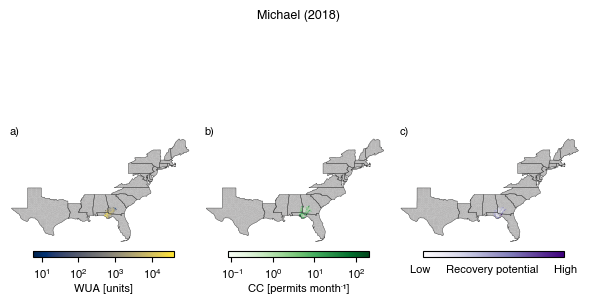

Laura (2020): 20 counties affected
  Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL132020_3panel_map.png


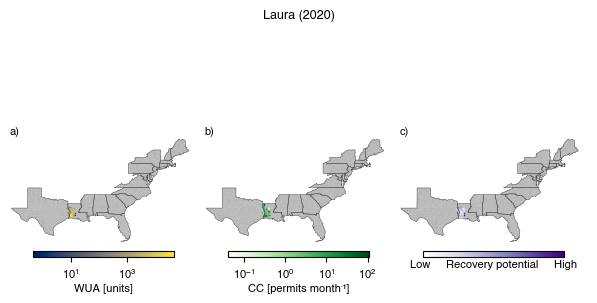

Harvey (2017): 9 counties affected
  Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL092017_3panel_map.png


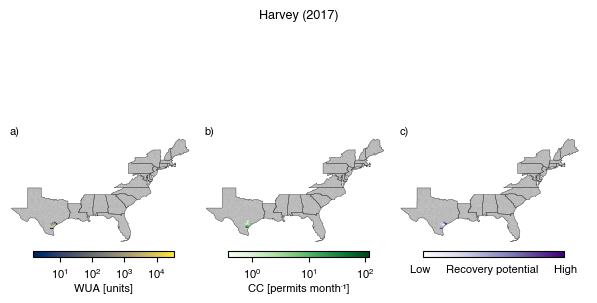

Irma (2017): 4 counties affected
  Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL112017_3panel_map.png


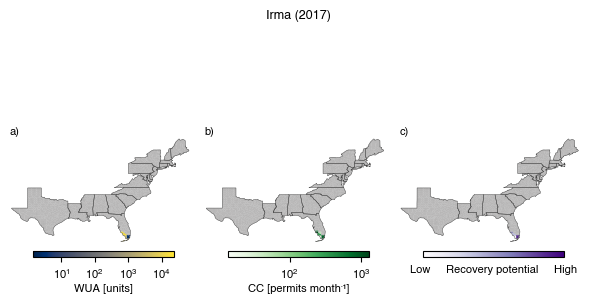

Isaac (2012): 1 counties affected
  Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL092012_3panel_map.png


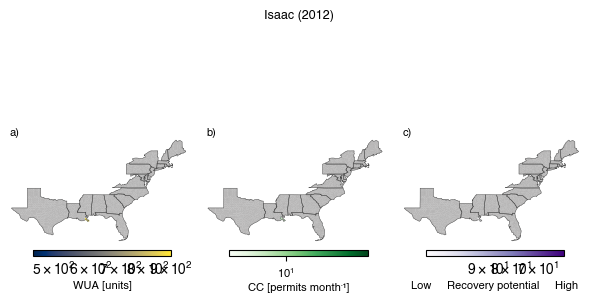

  AL092016: no impact CSVs — skipping
Katrina (2005): 16 counties affected
  Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL122005_3panel_map.png


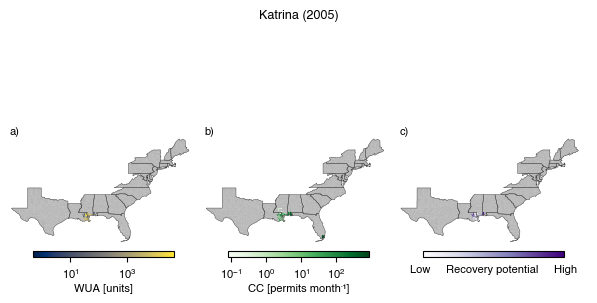

Ida (2021): 18 counties affected
  Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL092021_3panel_map.png


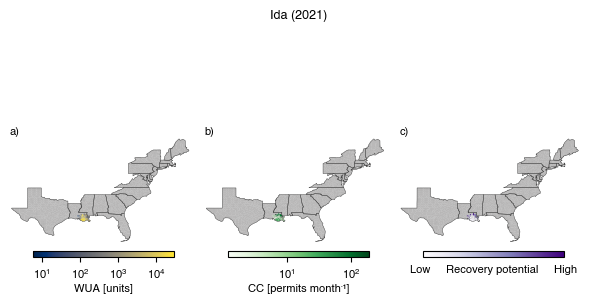

Ian (2022): 8 counties affected
  Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL092022_3panel_map.png


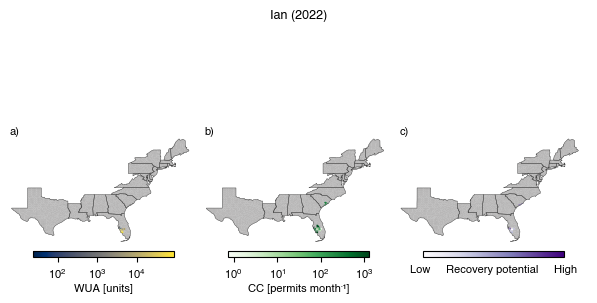

In [14]:
from matplotlib.colors import LogNorm

# ---- Style constants matching manuscript figures (create_manuscript_figures.py) ----
W_DOUBLE = 5.91   # 15.0 cm, double column
MAP_XLIM = (-107, -65)
MAP_YLIM = (24, 48)
NO_DATA_COLOR    = "#bab9b9"
COUNTY_EDGECOLOR = "#aaaaaa"
COUNTY_LINEWIDTH = 0.1
STATE_EDGECOLOR  = "#444444"
STATE_LINEWIDTH  = 0.3
CBAR_FS          = 8   # uniform colorbar fontsize

COASTAL_STATE_FIPS = [
    "01", "09", "10", "12", "13", "22", "23", "24", "25", "28",
    "33", "34", "36", "37", "42", "44", "45", "48", "51",
]

plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})

# ---- Load spatial base layers ----
counties_raw = gpd.read_file(str(COUNTIES_SHP))
if counties_raw.crs is None:
    counties_raw = counties_raw.set_crs("EPSG:4326")
coastal_counties = counties_raw[counties_raw["STATEFP"].isin(COASTAL_STATE_FIPS)].copy()
coastal_counties["GEOID"] = (coastal_counties["STATEFP"] + coastal_counties["COUNTYFP"]).str.zfill(5)
state_gdf = coastal_counties.dissolve(by="STATEFP").reset_index()
print(f"Coastal counties: {len(coastal_counties)}, states: {len(state_gdf)}")


def _choropleth_panel(gdf, state_gdf, ax, col, cmap, cbar_label,
                      invert_cbar=False, end_labels=None,
                      xlim=None, ylim=None):
    """Single choropleth panel matching manuscript figS2 layout.

    end_labels: ("Low", "High") tuple for the inverted recovery colorbar.
    xlim/ylim: override map extent (defaults to full US coast).
    """
    _xlim = xlim if xlim is not None else MAP_XLIM
    _ylim = ylim if ylim is not None else MAP_YLIM

    tmp = gdf[[col, "geometry"]].copy()
    tmp.loc[~(tmp[col] > 0), col] = np.nan
    valid = tmp[col].dropna()
    norm = None
    if len(valid) > 0:
        vmin, vmax = valid.min(), valid.max()
        if np.isfinite(vmin) and np.isfinite(vmax) and vmin > 0:
            norm = LogNorm(vmin=vmin / 2, vmax=vmax)

    cax = ax.inset_axes([0.125, -0.12, 0.75, 0.05])
    tmp.plot(
        column=col, cmap=cmap, norm=norm,
        edgecolor=COUNTY_EDGECOLOR, linewidth=COUNTY_LINEWIDTH,
        legend=True, ax=ax, cax=cax,
        legend_kwds={"orientation": "horizontal"},
        missing_kwds={"color": NO_DATA_COLOR,
                      "edgecolor": COUNTY_EDGECOLOR,
                      "linewidth": COUNTY_LINEWIDTH},
    )
    state_gdf.plot(ax=ax, facecolor="none",
                   edgecolor=STATE_EDGECOLOR, linewidth=STATE_LINEWIDTH)
    ax.set_xlim(_xlim)
    ax.set_ylim(_ylim)
    ax.set_aspect("equal")
    ax.axis("off")

    # Colorbar: uniform fontsize, label below the bar
    cax.tick_params(labelsize=CBAR_FS)
    cax.tick_params(which="minor", length=0)
    if invert_cbar:
        cax.invert_xaxis()
        cax.set_xticks([])
        # "Low … label … High" placed below the bar as one xlabel string
        _end = end_labels if end_labels is not None else ("Low", "High")
        cax.set_xlabel(f"{_end[0]}     {cbar_label}     {_end[1]}",
                       fontsize=CBAR_FS, labelpad=2)
    else:
        cax.set_xlabel(cbar_label, fontsize=CBAR_FS, labelpad=2)


RECOVERY_WEIGHTS = {1: 1, 2: 1, 3: 3, 4: 6}

per_event_dir = Path(IMPACT_DIR_HIST) / 'per_event'

for atcf_id in haz_atcf_ids:
    event_csvs = sorted(per_event_dir.glob(f"*_{atcf_id}.csv"))
    if not event_csvs:
        print(f"  {atcf_id}: no impact CSVs — skipping")
        continue

    impact_df = pd.concat([pd.read_csv(f) for f in event_csvs], ignore_index=True)
    impact_df["fips"] = impact_df["fips"].astype(str).str.zfill(5)
    impact_df["weighted_damage"] = sum(
        impact_df[f"units_DS{k}_scaled"] * RECOVERY_WEIGHTS[k] for k in [1, 2, 3, 4]
    )

    rec_ev = recovery[recovery["event_name"] == atcf_id].copy()
    rec_ev["fips"] = rec_ev["fips"].astype(str).str.zfill(5)
    rec_ev["cc"] = rec_ev["reconstruction_capacity"]   # already permits/month
    rec_ev = rec_ev.rename(columns={"recovery_potential_months": "recovery_months"})

    ev_df = impact_df[["fips", "weighted_damage"]].merge(
        rec_ev[["fips", "cc", "recovery_months"]], on="fips", how="outer"
    )

    gdf = coastal_counties.merge(ev_df, left_on="GEOID", right_on="fips", how="left")
    for col in ("weighted_damage", "cc", "recovery_months"):
        gdf.loc[~(gdf[col] > 0), col] = np.nan

    n_aff = int((gdf["weighted_damage"] > 0).sum())
    print(f"{STORM_LABEL.get(atcf_id, atcf_id)}: {n_aff} counties affected")

    fig, axes = plt.subplots(1, 3, figsize=(W_DOUBLE, 3.3))
    panels = [
        ("weighted_damage", "cividis",   "WUA [units]",          False, None),
        ("cc",              "Greens",    "CC [permits month⁻¹]", False, None),
        ("recovery_months", "Purples_r", "Recovery potential",    True,  ("Low", "High")),
    ]
    for ax, (col, cmap, cbar_label, inv, end_lbls), lbl in zip(axes, panels, ["a", "b", "c"]):
        _choropleth_panel(gdf, state_gdf, ax, col, cmap, cbar_label,
                          invert_cbar=inv, end_labels=end_lbls)
        ax.set_title(f"{lbl})", loc="left", fontsize=8, fontweight="bold", pad=2)

    fig.suptitle(STORM_LABEL.get(atcf_id, atcf_id), fontsize=9, y=1.02)
    plt.tight_layout(pad=0.5)
    out_fp = FIGURES_DIR / f"hist_{atcf_id}_3panel_map.png"
    fig.savefig(out_fp, dpi=300, bbox_inches="tight")
    print(f"  Saved → {out_fp}")
    plt.show()


## Focus: Michael (2018) and Laura (2020)

Cropped three-panel maps showing only the affected region, plus county-level tables.  
WUA = Weighted Units Affected (Σ units_DS*k* × TAU*k*, TAU = {DS1:1, DS2:1, DS3:3, DS4:6}).  
CC = Construction Capacity (average monthly building permits over the past 12 months).  
"Unscaled" columns use raw wind-only damage; "scaled" columns include compound rain/surge scaling.

Michael (2018): 41 counties  |  lon -87.7–-81.5, lat 28.1–33.8
  Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL142018_4panel_focus.png


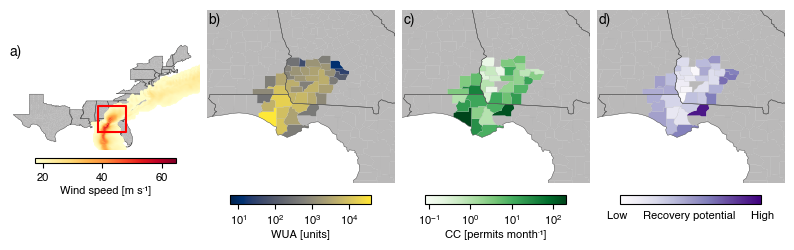

Laura (2020): 20 counties  |  lon -96.0–-90.6, lat 28.1–33.8
  Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL132020_4panel_focus.png


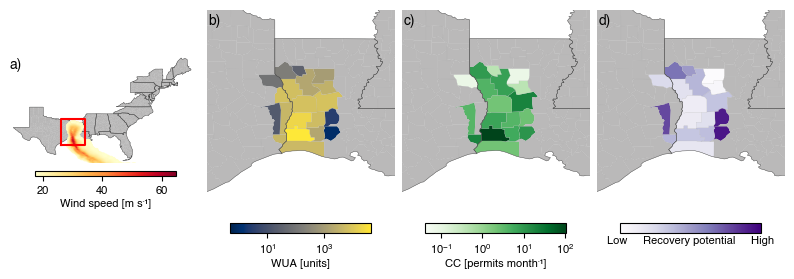

In [15]:
import matplotlib.patches as mpatches

# ---- Focus: Michael and Laura — 4-panel maps ----
# a: Wind footprint overview (19 coastal states) with red box marking the inset extent
# b–d: Regional detail (WUA, CC, Recovery potential)

FOCUS_ATCF = ['AL142018', 'AL132020']
PAD_DEG    = 1.5
WIND_THRESH = 17.5   # m/s (tropical-storm strength)

for atcf_id in FOCUS_ATCF:
    if atcf_id not in haz_atcf_ids:
        print(f"{atcf_id}: not in this run — skipping")
        continue

    event_csvs = sorted(per_event_dir.glob(f"*_{atcf_id}.csv"))
    if not event_csvs:
        print(f"  {atcf_id}: no impact CSVs — skipping")
        continue

    impact_df = pd.concat([pd.read_csv(f) for f in event_csvs], ignore_index=True)
    impact_df["fips"] = impact_df["fips"].astype(str).str.zfill(5)
    impact_df["weighted_damage"] = sum(
        impact_df[f"units_DS{k}_scaled"] * RECOVERY_WEIGHTS[k] for k in [1, 2, 3, 4]
    )

    rec_ev = recovery[recovery["event_name"] == atcf_id].copy()
    rec_ev["fips"] = rec_ev["fips"].astype(str).str.zfill(5)
    rec_ev["cc"] = rec_ev["reconstruction_capacity"]   # already permits/month
    rec_ev = rec_ev.rename(columns={"recovery_potential_months": "recovery_months"})

    ev_df = impact_df[["fips", "weighted_damage"]].merge(
        rec_ev[["fips", "cc", "recovery_months"]], on="fips", how="outer"
    )

    gdf = coastal_counties.merge(ev_df, left_on="GEOID", right_on="fips", how="left")
    for col in ("weighted_damage", "cc", "recovery_months"):
        gdf.loc[~(gdf[col] > 0), col] = np.nan
    # CC only where the county has non-zero damage
    gdf.loc[gdf["weighted_damage"].isna(), "cc"] = np.nan

    affected = gdf[gdf["weighted_damage"] > 0]
    if affected.empty:
        print(f"  {atcf_id}: no affected counties — skipping")
        continue
    b = affected.total_bounds
    crop_xlim = (b[0] - PAD_DEG, b[2] + PAD_DEG)
    crop_ylim = (b[1] - PAD_DEG, b[3] + PAD_DEG)

    n_aff = int((gdf["weighted_damage"] > 0).sum())
    print(f"{STORM_LABEL.get(atcf_id, atcf_id)}: {n_aff} counties  |  "
          f"lon {crop_xlim[0]:.1f}–{crop_xlim[1]:.1f}, lat {crop_ylim[0]:.1f}–{crop_ylim[1]:.1f}")

    # ---- Wind footprint ----
    ev_idx = list(haz_hist.event_name).index(atcf_id)
    wind   = haz_hist.intensity[ev_idx, :].toarray().ravel()
    lons_h = haz_hist.centroids.lon
    lats_h = haz_hist.centroids.lat
    wmask  = wind > WIND_THRESH

    # ---- 4-panel figure ----
    fig, axes = plt.subplots(1, 4, figsize=(W_DOUBLE * 4 / 3, 3.3))

    # Panel a — wind overview + red inset box
    ax0 = axes[0]
    coastal_counties.plot(ax=ax0, color=NO_DATA_COLOR,
                          edgecolor=COUNTY_EDGECOLOR, linewidth=COUNTY_LINEWIDTH)
    state_gdf.plot(ax=ax0, facecolor="none",
                   edgecolor=STATE_EDGECOLOR, linewidth=STATE_LINEWIDTH)
    if wmask.any():
        sc = ax0.scatter(lons_h[wmask], lats_h[wmask], c=wind[wmask],
                         s=2, cmap="YlOrRd", vmin=WIND_THRESH, vmax=65,
                         rasterized=True, zorder=3)
        cax0 = ax0.inset_axes([0.125, -0.12, 0.75, 0.05])
        plt.colorbar(sc, cax=cax0, orientation="horizontal")
        cax0.tick_params(labelsize=CBAR_FS)
        cax0.tick_params(which="minor", length=0)
        cax0.set_xlabel("Wind speed [m s⁻¹]", fontsize=CBAR_FS, labelpad=2)
    # Red box marking the regional inset
    ax0.plot(
        [crop_xlim[0], crop_xlim[1], crop_xlim[1], crop_xlim[0], crop_xlim[0]],
        [crop_ylim[0], crop_ylim[0], crop_ylim[1], crop_ylim[1], crop_ylim[0]],
        color="red", linewidth=1.5, zorder=5,
    )
    ax0.set_xlim(MAP_XLIM)
    ax0.set_ylim(MAP_YLIM)
    ax0.set_aspect("equal")
    ax0.axis("off")
    ax0.text(-0.01, 0.98, "a)", transform=ax0.transAxes,
             ha="left", va="top", fontsize=10, fontweight="bold")

    # Panels b–d — regional detail
    panels = [
        ("weighted_damage", "cividis",   "WUA [units]",          False, None),
        ("cc",              "Greens",    "CC [permits month⁻¹]", False, None),
        ("recovery_months", "Purples_r", "Recovery potential",    True,  ("Low", "High")),
    ]
    for ax, (col, cmap, cbar_label, inv, end_lbls), lbl in zip(axes[1:], panels, ["b", "c", "d"]):
        _choropleth_panel(gdf, state_gdf, ax, col, cmap, cbar_label,
                          invert_cbar=inv, end_labels=end_lbls,
                          xlim=crop_xlim, ylim=crop_ylim)
        ax.text(0.01, 0.98, f"{lbl})", transform=ax.transAxes,
                ha="left", va="top", fontsize=10, fontweight="bold")

    plt.tight_layout(pad=0.5)
    out_fp = FIGURES_DIR / f"hist_{atcf_id}_4panel_focus.png"
    fig.savefig(out_fp, dpi=300, bbox_inches="tight")
    print(f"  Saved → {out_fp}")
    plt.show()


In [16]:
from IPython.display import display

# ---- State FIPS → name lookup ----
STATE_FIPS_TO_NAME = {
    "01": "Alabama",       "09": "Connecticut",    "10": "Delaware",
    "12": "Florida",       "13": "Georgia",        "22": "Louisiana",
    "23": "Maine",         "24": "Maryland",       "25": "Massachusetts",
    "28": "Mississippi",   "33": "New Hampshire",  "34": "New Jersey",
    "36": "New York",      "37": "North Carolina", "42": "Pennsylvania",
    "44": "Rhode Island",  "45": "South Carolina", "48": "Texas",
    "51": "Virginia",
}
county_info = (
    coastal_counties[["GEOID", "NAME", "STATEFP"]]
    .assign(county_name=lambda d: d["NAME"],
            state_name=lambda d: d["STATEFP"].map(STATE_FIPS_TO_NAME))
    [["GEOID", "county_name", "state_name"]]
)

FOCUS_STORMS = {
    'AL142018': ('Michael', 2018),
    'AL132020': ('Laura',   2020),
}
TAU = {1: 1, 2: 1, 3: 3, 4: 6}

table_dfs = []
for atcf_id, (tc_name, tc_year) in FOCUS_STORMS.items():
    event_csvs = sorted(per_event_dir.glob(f"*_{atcf_id}.csv"))
    if not event_csvs:
        continue
    impact = pd.concat([pd.read_csv(f) for f in event_csvs], ignore_index=True)
    impact["fips"] = impact["fips"].astype(str).str.zfill(5)

    # Weighted units affected (WUA = Σ units_DSk × TAU[k])
    impact["wua_raw"]    = sum(impact[f"units_DS{k}_raw"]    * TAU[k] for k in [1, 2, 3, 4])
    impact["wua_scaled"] = sum(impact[f"units_DS{k}_scaled"] * TAU[k] for k in [1, 2, 3, 4])

    # Floor for unscaled recovery = TAU of highest DS with any raw units
    impact["floor_raw"] = 0
    for k in [1, 2, 3, 4]:
        impact["floor_raw"] = np.where(
            impact[f"units_DS{k}_raw"] > 0, TAU[k], impact["floor_raw"]
        )

    # reconstruction_capacity is already in permits/month (Average_Building_Permits(12 months)
    # stores the monthly average over the past year — no /12 needed).
    rec_ev = recovery[recovery["event_name"] == atcf_id].copy()
    rec_ev["fips"] = rec_ev["fips"].astype(str).str.zfill(5)

    merged = impact.merge(
        rec_ev[["fips", "reconstruction_capacity", "recovery_potential_months"]],
        on="fips", how="left"
    )

    # Unscaled recovery uses the same formula as cell-19: demand / cap (permits/month) → months.
    merged["recov_raw"] = np.where(
        merged["reconstruction_capacity"] > 0,
        np.maximum(merged["floor_raw"],
                   merged["wua_raw"] / merged["reconstruction_capacity"]),
        np.nan,
    )

    merged = merged.merge(county_info, left_on="fips", right_on="GEOID", how="left")
    merged = merged[merged["wua_scaled"] > 0].copy()
    merged["TC"]   = tc_name
    merged["year"] = tc_year

    table_dfs.append(merged[[
        "TC", "year", "state_name", "county_name",
        "wua_raw", "wua_scaled",
        "reconstruction_capacity",
        "recov_raw", "recovery_potential_months",
        "repair_cost_sum_raw", "repair_cost_sum_scaled",
    ]])

table_df = pd.concat(table_dfs, ignore_index=True).sort_values(
    ["TC", "state_name", "county_name"], ignore_index=True
)
table_df.columns = [
    "TC", "Year", "State", "County",
    "WUA (raw)", "WUA (scaled)",
    "Permits / month",
    "Recovery unscaled (mo)", "Recovery scaled (mo)",
    "Repair cost raw ($)", "Repair cost scaled ($)",
]

fmt_dict = {
    "WUA (raw)":              "{:.0f}",
    "WUA (scaled)":           "{:.0f}",
    "Permits / month":        "{:.1f}",
    "Recovery unscaled (mo)": "{:.1f}",
    "Recovery scaled (mo)":   "{:.1f}",
    "Repair cost raw ($)":    "{:,.0f}",
    "Repair cost scaled ($)": "{:,.0f}",
}

for tc in ["Michael", "Laura"]:
    sub = table_df[table_df["TC"] == tc].reset_index(drop=True)
    yr  = int(sub["Year"].iloc[0]) if not sub.empty else ""
    print(f"\n{'='*60}")
    print(f"  {tc} ({yr})  —  {len(sub)} counties with scaled damage")
    print(f"{'='*60}")
    display(
        sub.drop(columns=["TC", "Year"])
           .style.format(fmt_dict)
           .set_caption(f"Hurricane {tc} ({yr})")
    )
    total_raw    = sub["Repair cost raw ($)"].sum()
    total_scaled = sub["Repair cost scaled ($)"].sum()
    print(f"  Total repair cost raw:    ${total_raw:,.0f}")
    print(f"  Total repair cost scaled: ${total_scaled:,.0f}")


  Michael (2018)  —  41 counties with scaled damage


,State,County,WUA (raw),WUA (scaled),Permits / month,Recovery unscaled (mo),Recovery scaled (mo),Repair cost raw ($),Repair cost scaled ($)
0,Alabama,Dale,564,564,3.2,178.1,178.1,"1,563,782","1,768,779"
1,Alabama,Geneva,937,937,3.2,288.3,288.3,"2,600,957","2,880,631"
2,Alabama,Henry,2006,3254,5.9,339.0,550.0,"12,074,083","13,523,342"
3,Alabama,Houston,10347,10347,38.6,268.2,268.2,"67,768,293","72,749,180"
4,Florida,Bay,40032,40032,206.1,194.3,194.3,"311,269,687","332,428,928"
5,Florida,Calhoun,8973,8973,2.5,3589.2,3589.2,"63,755,180","67,715,578"
6,Florida,Franklin,538,541,9.4,57.1,57.5,"1,650,427","2,035,962"
7,Florida,Gadsden,6948,8319,8.9,779.2,933.0,"41,501,013","45,620,905"
8,Florida,Gulf,10782,11101,25.2,428.4,441.1,"117,949,426","124,258,886"
9,Florida,Holmes,238,314,1.0,238.0,314.0,"797,096","903,246"



  Laura (2020)  —  20 counties with scaled damage


,State,County,WUA (raw),WUA (scaled),Permits / month,Recovery unscaled (mo),Recovery scaled (mo),Repair cost raw ($),Repair cost scaled ($)
0,Louisiana,Acadia,1,1,11.4,1.0,1.0,"4,200","5,936"
1,Louisiana,Allen,4108,5464,3.8,1071.7,1425.4,"129,614,302","172,539,442"
2,Louisiana,Beauregard,14934,19746,6.9,2159.1,2854.8,"178,965,550","224,827,695"
3,Louisiana,Calcasieu,42530,43859,108.2,393.2,405.5,"570,215,011","657,721,226"
4,Louisiana,Cameron,4886,4886,2.2,2171.6,2171.6,"101,599,421","109,296,443"
5,Louisiana,De Soto,162,162,9.4,17.2,17.2,"2,062,916","2,062,916"
6,Louisiana,Evangeline,3,3,2.3,1.3,1.3,"13,104","18,698"
7,Louisiana,Grant,3146,3146,0.4,7550.4,7550.4,"19,842,731","19,842,731"
8,Louisiana,Jefferson Davis,1444,1711,5.8,251.1,297.6,"35,893,055","48,243,967"
9,Louisiana,Natchitoches,1742,1742,7.9,220.0,220.0,"5,503,263","5,503,263"


## Step 6 — Huang (2025) validation

In [17]:
# ---- Load Huang dataset ----
huang = pd.read_csv(HUANG_CSV)
huang['GEOID'] = huang['GEOID'].astype(str).str.zfill(5)
print(f'Huang rows: {len(huang)}')
print(f'Huang storms (atcf_id): {sorted(huang["atcf_id"].unique())}')
huang.head(3)

Huang rows: 103
Huang storms (atcf_id): ['AL092012', 'AL092016', 'AL092017', 'AL112017', 'AL132020', 'AL142016', 'AL142018', 'AL162017', 'AL182012']


,GEOID,county,state,event,year,atcf_id,n_changed,n_improved,n_equal,n_abandoned,improvement_rate,rebuild_rate,abandonment_rate,recovery_score,COAST,HAZARD
0,22019,Calcasieu,LA,Hurricane Harvey,2017,AL092017,5,0,1,4,0.0000,0.2000,0.8000,-0.8,0,0
1,48007,Aransas,TX,Hurricane Harvey,2017,AL092017,50,25,10,15,0.5000,0.7000,0.3000,0.2,166,0
2,48039,Brazoria,TX,Hurricane Harvey,2017,AL092017,3,1,1,1,0.3333,0.6667,0.3333,0.0,163,0


In [18]:
# ---- Prepare recovery table for join ----
rec_eval = recovery.copy()
rec_eval['fips5'] = rec_eval['fips'].astype(str).apply(lambda x: x.zfill(5))

# ---- Join on (fips5, atcf_id) ----
joined = huang.merge(
    rec_eval[['event_name', 'fips5', 'recovery_potential_months', 'reconstruction_capacity']],
    left_on  = ['GEOID', 'atcf_id'],
    right_on = ['fips5', 'event_name'],
    how      = 'inner',
)

print(f'Joined rows (before filtering): {len(joined)}')
print(f'Events in joined set: {sorted(joined["atcf_id"].unique())}')

Joined rows (before filtering): 28
Events in joined set: ['AL092012', 'AL092017', 'AL112017', 'AL132020', 'AL142018']


In [19]:
# ---- Filter: restrict to 7 Huang comparison storms, exclude illustrations ----
# Also filter missing blended storms so we only keep events we actually computed
comparison_atcf = [a for a in HUANG_ATCF_IDS if a in haz_atcf_ids]
print(f'Huang ATCF IDs requested: {HUANG_ATCF_IDS}')
print(f'Available in our run: {comparison_atcf}')
not_available = [a for a in HUANG_ATCF_IDS if a not in haz_atcf_ids]
if not_available:
    print(f'WARNING: {not_available} missing from blended set — excluded from evaluation')

eval_df = joined[
    joined['atcf_id'].isin(comparison_atcf) &
    (joined['n_changed'] >= 30) &
    joined['recovery_potential_months'].notna()
].copy()

print(f'\nAfter filters (comparison storms, n_changed≥30, non-NaN recovery):')
print(f'  Rows: {len(eval_df)}')
print(f'  Events: {sorted(eval_df["atcf_id"].unique())}')
print(f'  Counties: {eval_df["GEOID"].nunique()}')
eval_df.head(5)

Huang ATCF IDs requested: ['AL142018', 'AL132020', 'AL092017', 'AL112017', 'AL092012', 'AL092016']
Available in our run: ['AL142018', 'AL132020', 'AL092017', 'AL112017', 'AL092012', 'AL092016']

After filters (comparison storms, n_changed≥30, non-NaN recovery):
  Rows: 10
  Events: ['AL092017', 'AL112017', 'AL132020', 'AL142018']
  Counties: 10


,GEOID,county,state,event,year,atcf_id,n_changed,n_improved,n_equal,n_abandoned,improvement_rate,rebuild_rate,abandonment_rate,recovery_score,COAST,HAZARD,event_name,fips5,recovery_potential_months,reconstruction_capacity
0,48007,Aransas,TX,Hurricane Harvey,2017,AL092017,50,25,10,15,0.5000,0.7000,0.3000,0.2000,166,0,AL092017,48007,2061.882353,17.000000
2,48273,Kleberg,TX,Hurricane Harvey,2017,AL092017,293,168,54,71,0.5734,0.7577,0.2423,0.3311,168,0,AL092017,48273,3.000000,2.000000
5,48469,Victoria,TX,Hurricane Harvey,2017,AL092017,32,9,8,15,0.2812,0.5312,0.4688,-0.1876,0,0,AL092017,48469,5.023256,3.583333
7,12021,Collier,FL,Hurricane Irma,2017,AL112017,294,191,47,56,0.6497,0.8095,0.1905,0.4592,123,0,AL112017,12021,47.965909,293.333333
8,12071,Lee,FL,Hurricane Irma,2017,AL112017,63,46,9,8,0.7302,0.8730,0.1270,0.6032,124,0,AL112017,12071,18.532217,1284.250000


Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL142018_2x2_comparison.png


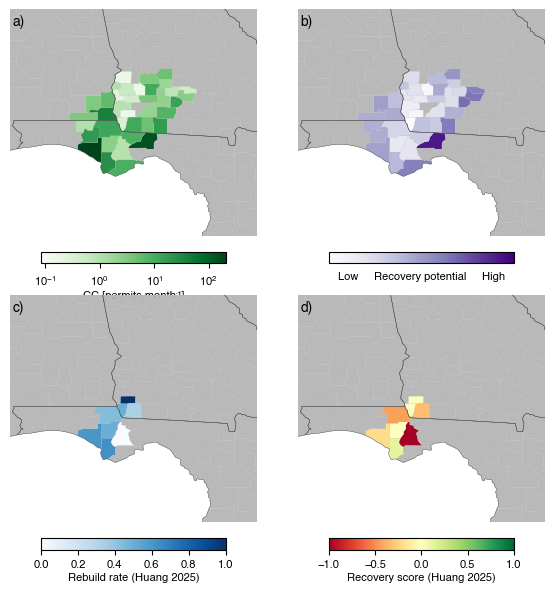

Saved → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/hist_AL132020_2x2_comparison.png


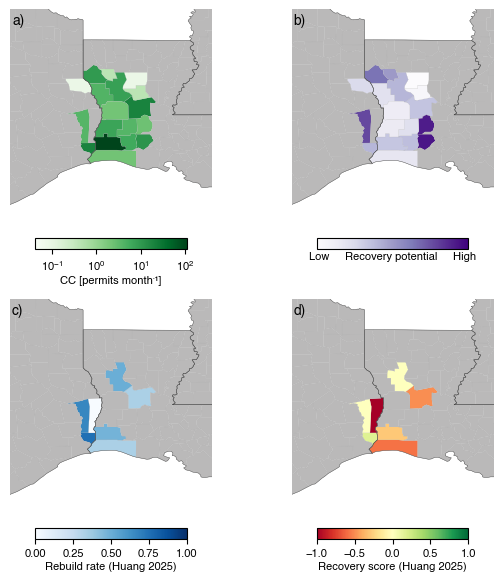

In [20]:
# ---- 2×2 comparison maps: model vs Huang observed ----
# Top row   : CC (our study) | Recovery potential (our study)
# Bottom row: Rebuild rate (Huang 2025) | Recovery score (Huang 2025)
# One figure per storm; cropped to the storm's affected region.

from matplotlib.colors import Normalize, TwoSlopeNorm

CBAR_FS = 8   # uniform colorbar fontsize across all panels


def _panel_flex(gdf, state_gdf, ax, col, cmap, cbar_label,
                norm=None, xlim=None, ylim=None,
                invert_cbar=False, end_labels=None):
    """Choropleth panel accepting an arbitrary matplotlib norm."""
    _xlim = xlim if xlim is not None else MAP_XLIM
    _ylim = ylim if ylim is not None else MAP_YLIM

    tmp = gdf[[col, "geometry"]].copy()
    cax = ax.inset_axes([0.125, -0.12, 0.75, 0.05])
    tmp.plot(
        column=col, cmap=cmap, norm=norm,
        edgecolor=COUNTY_EDGECOLOR, linewidth=COUNTY_LINEWIDTH,
        legend=True, ax=ax, cax=cax,
        legend_kwds={"orientation": "horizontal"},
        missing_kwds={"color": NO_DATA_COLOR,
                      "edgecolor": COUNTY_EDGECOLOR,
                      "linewidth": COUNTY_LINEWIDTH},
    )
    state_gdf.plot(ax=ax, facecolor="none",
                   edgecolor=STATE_EDGECOLOR, linewidth=STATE_LINEWIDTH)
    ax.set_xlim(_xlim); ax.set_ylim(_ylim)
    ax.set_aspect("equal"); ax.axis("off")

    # Colorbar: uniform fontsize, label below the bar
    cax.tick_params(labelsize=CBAR_FS)
    cax.tick_params(which="minor", length=0)
    if invert_cbar:
        cax.invert_xaxis()
        cax.set_xticks([])
        # "Low … label … High" placed below the bar as one xlabel string
        _end = end_labels if end_labels else ("Low", "High")
        cax.set_xlabel(f"{_end[0]}     {cbar_label}     {_end[1]}",
                       fontsize=CBAR_FS, labelpad=2)
    else:
        cax.set_xlabel(cbar_label, fontsize=CBAR_FS, labelpad=2)


for atcf_id in FOCUS_ATCF:
    if atcf_id not in haz_atcf_ids:
        continue

    storm_label = STORM_LABEL.get(atcf_id, atcf_id)

    # Load impact to determine which counties have non-zero affected units
    event_csvs = sorted(per_event_dir.glob(f"*_{atcf_id}.csv"))
    if event_csvs:
        impact_df = pd.concat([pd.read_csv(f) for f in event_csvs], ignore_index=True)
        impact_df["fips"] = impact_df["fips"].astype(str).str.zfill(5)
        impact_df["weighted_damage"] = sum(
            impact_df[f"units_DS{k}_scaled"] * RECOVERY_WEIGHTS[k] for k in [1, 2, 3, 4]
        )
        aff_fips = set(impact_df.loc[impact_df["weighted_damage"] > 0, "fips"])
    else:
        aff_fips = set()

    # Our recovery data
    rec_ev = recovery[recovery["event_name"] == atcf_id].copy()
    rec_ev["fips"] = rec_ev["fips"].astype(str).str.zfill(5)

    # Huang data — all counties (no n_changed filter for maps)
    huang_ev = huang[huang["atcf_id"] == atcf_id][
        ["GEOID", "rebuild_rate", "recovery_score"]
    ].copy()
    huang_ev["GEOID"] = huang_ev["GEOID"].astype(str).str.zfill(5)

    gdf_cmp = coastal_counties.merge(
        rec_ev[["fips", "reconstruction_capacity", "recovery_potential_months"]],
        left_on="GEOID", right_on="fips", how="left",
    ).merge(huang_ev, on="GEOID", how="left")

    gdf_cmp = gdf_cmp.copy()

    # CC: only show counties with non-zero affected units
    gdf_cmp.loc[~gdf_cmp["GEOID"].isin(aff_fips), "reconstruction_capacity"] = np.nan

    # For log-normed columns, zero/negative values are not plottable → NaN
    for _col in ("reconstruction_capacity", "recovery_potential_months"):
        gdf_cmp.loc[~(gdf_cmp[_col] > 0), _col] = np.nan

    # Crop extent from affected counties
    aff_mask = gdf_cmp["recovery_potential_months"].notna()
    if not aff_mask.any():
        print(f"  {atcf_id}: no affected counties — skipping")
        continue
    b = gdf_cmp[aff_mask].total_bounds
    crop_xlim = (b[0] - PAD_DEG, b[2] + PAD_DEG)
    crop_ylim = (b[1] - PAD_DEG, b[3] + PAD_DEG)

    # Norms — computed from already-filtered positive values
    cc_pos = gdf_cmp["reconstruction_capacity"].dropna()
    cc_norm = LogNorm(vmin=cc_pos.min() / 2, vmax=cc_pos.max()) if len(cc_pos) > 0 else None

    rp_pos = gdf_cmp["recovery_potential_months"].dropna()
    rp_norm = LogNorm(vmin=rp_pos.min() / 2, vmax=rp_pos.max()) if len(rp_pos) > 0 else None

    rr_norm = Normalize(vmin=0, vmax=1)

    rs_norm = Normalize(vmin=-1, vmax=1)

    fig, axes = plt.subplots(2, 2, figsize=(W_DOUBLE, W_DOUBLE))

    _panel_flex(gdf_cmp, state_gdf, axes[0, 0],
                "reconstruction_capacity", "Greens", "CC [permits month⁻¹]",
                norm=cc_norm, xlim=crop_xlim, ylim=crop_ylim)

    _panel_flex(gdf_cmp, state_gdf, axes[0, 1],
                "recovery_potential_months", "Purples_r", "Recovery potential",
                norm=rp_norm, invert_cbar=True, end_labels=("Low", "High"),
                xlim=crop_xlim, ylim=crop_ylim)

    _panel_flex(gdf_cmp, state_gdf, axes[1, 0],
                "rebuild_rate", "Blues", "Rebuild rate (Huang 2025)",
                norm=rr_norm, xlim=crop_xlim, ylim=crop_ylim)

    _panel_flex(gdf_cmp, state_gdf, axes[1, 1],
                "recovery_score", "RdYlGn", "Recovery score (Huang 2025)",
                norm=rs_norm, xlim=crop_xlim, ylim=crop_ylim)

    # Panel labels: slightly left of the left edge and below the top
    for ax, lbl in zip(axes.ravel(), ["a)", "b)", "c)", "d)"]):
        ax.text(0.01, 0.98, lbl, transform=ax.transAxes,
                ha="left", va="top", fontsize=10, fontweight="bold")

    #plt.tight_layout(pad=0.5)
    plt.tight_layout()
    out_fp = FIGURES_DIR / f"hist_{atcf_id}_2x2_comparison.png"
    fig.savefig(out_fp, dpi=300, bbox_inches="tight")
    print(f"Saved → {out_fp}")
    plt.show()


In [21]:
# ---- Spearman rank correlations ----
# Ranking of counties within each event; pooled over all events.
# Expected signs:
#   recovery_potential_months vs recovery_score   → negative (longer RP = worse outcome)
#   reconstruction_capacity   vs rebuild_rate     → positive (more CC = more rebuilding)
#   recovery_potential_months vs abandonment_rate → positive (longer RP = more abandonment)

results = []

def spearman_row(label, df, x_col, y_col):
    sub = df[[x_col, y_col]].dropna()
    if len(sub) < 5:
        return dict(label=label, x_col=x_col, y_col=y_col, n=len(sub), rho=np.nan, p=np.nan)
    rho, p = spearmanr(sub[x_col], sub[y_col])
    return dict(label=label, x_col=x_col, y_col=y_col,
                n=len(sub), rho=round(rho, 3), p=round(p, 4))

CORR_PAIRS = [
    ('recovery_potential_months', 'recovery_score',   '< 0'),
    ('reconstruction_capacity',   'rebuild_rate',     '> 0'),
    ('recovery_potential_months', 'abandonment_rate', '> 0'),
]

for x_col, y_col, sign in CORR_PAIRS:
    header = f"{x_col}  vs  {y_col}"
    print(f'\n=== Spearman ρ: {header}  (expected ρ {sign}) ===')
    print(f"{'Event':<22} {'n':>5} {'ρ':>8} {'p-value':>10}")
    print('-' * 52)
    for aid in sorted(eval_df['atcf_id'].unique()):
        sub = eval_df[eval_df['atcf_id'] == aid]
        r = spearman_row(STORM_LABEL.get(aid, aid), sub, x_col, y_col)
        sig = '*' if (not np.isnan(r['rho']) and r['p'] < 0.05) else ' '
        print(f"{r['label']:<22} {r['n']:>5} {r['rho']:>8.3f} {r['p']:>10.4f} {sig}")
        results.append(r)
    r_pool = spearman_row('POOLED', eval_df, x_col, y_col)
    sig = '*' if (not np.isnan(r_pool['rho']) and r_pool['p'] < 0.05) else ' '
    print(f"{'POOLED':<22} {r_pool['n']:>5} {r_pool['rho']:>8.3f} {r_pool['p']:>10.4f} {sig}")
    results.append(r_pool)

results_df = pd.DataFrame(results)
results_csv = FIGURES_DIR / 'huang_spearman_results.csv'
results_df.to_csv(results_csv, index=False)
print(f'\nSaved correlation results → {results_csv}')
print('(* p < 0.05)')


=== Spearman ρ: recovery_potential_months  vs  recovery_score  (expected ρ < 0) ===
Event                      n        ρ    p-value
----------------------------------------------------
Harvey (2017)              3      nan        nan  
Irma (2017)                4      nan        nan  
Laura (2020)               1      nan        nan  
Michael (2018)             2      nan        nan  
POOLED                    10   -0.328     0.3544  

=== Spearman ρ: reconstruction_capacity  vs  rebuild_rate  (expected ρ > 0) ===
Event                      n        ρ    p-value
----------------------------------------------------
Harvey (2017)              3      nan        nan  
Irma (2017)                4      nan        nan  
Laura (2020)               1      nan        nan  
Michael (2018)             2      nan        nan  
POOLED                    10    0.455     0.1869  

=== Spearman ρ: recovery_potential_months  vs  abandonment_rate  (expected ρ > 0) ===
Event                      n     

Saved scatter figure → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/huang_scatter.png


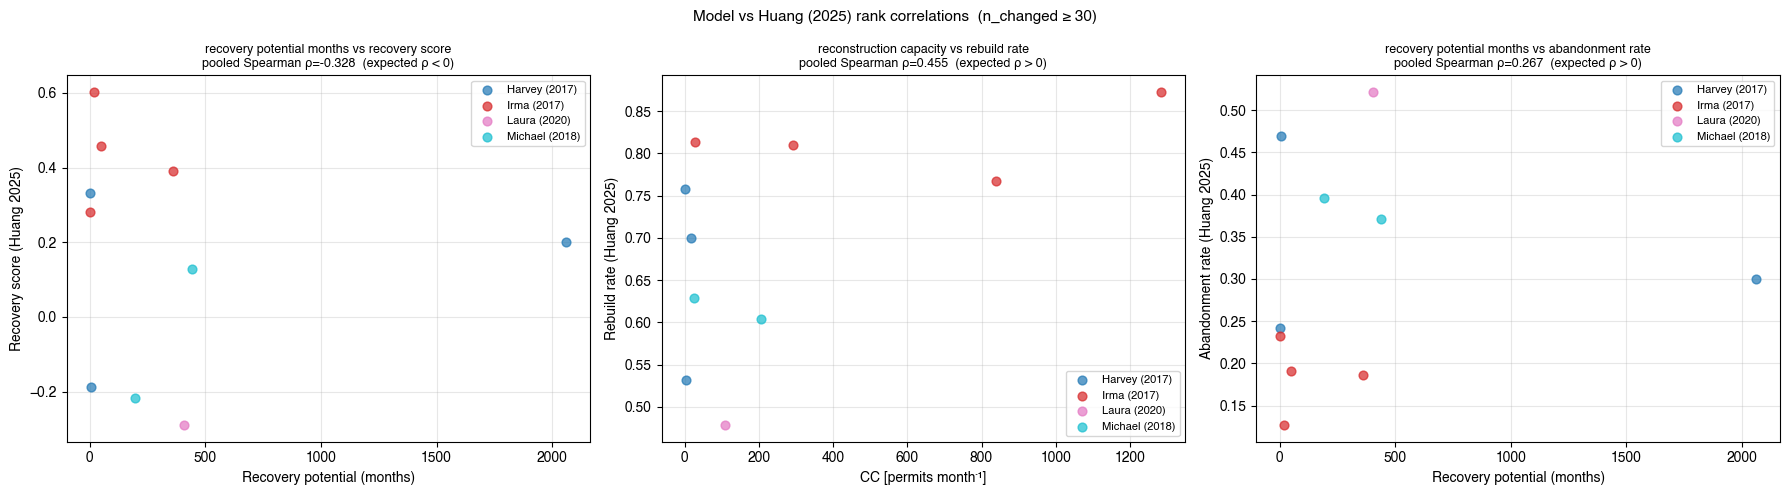

In [22]:
# ---- Scatter plots: all three correlation pairs ----
events_eval = sorted(eval_df['atcf_id'].unique())
colors_ev   = plt.cm.tab10(np.linspace(0, 1, max(len(events_eval), 1)))

SCATTER_TRIPLES = [
    ('recovery_potential_months', 'recovery_score',
     'Recovery potential (months)', 'Recovery score (Huang 2025)', 'expected ρ < 0'),
    ('reconstruction_capacity',   'rebuild_rate',
     'CC [permits month⁻¹]',       'Rebuild rate (Huang 2025)',   'expected ρ > 0'),
    ('recovery_potential_months', 'abandonment_rate',
     'Recovery potential (months)', 'Abandonment rate (Huang 2025)', 'expected ρ > 0'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x_col, y_col, x_label, y_label, sign_label) in zip(axes, SCATTER_TRIPLES):
    for ev_color, aid in zip(colors_ev, events_eval):
        sub = eval_df[eval_df['atcf_id'] == aid]
        ax.scatter(
            sub[x_col], sub[y_col],
            s=40, alpha=0.7, color=ev_color,
            label=STORM_LABEL.get(aid, aid), zorder=3,
        )
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.legend(fontsize=8, ncol=1, loc='best')
    ax.grid(True, alpha=0.3)
    pooled_row = results_df[
        (results_df['x_col'] == x_col) &
        (results_df['y_col'] == y_col) &
        (results_df['label'] == 'POOLED')
    ]
    rho_str = f"ρ={pooled_row['rho'].values[0]:.3f}" if not pooled_row.empty else ''
    ax.set_title(
        f"{x_col.replace('_',' ')} vs {y_col.replace('_',' ')}\n"
        f"pooled Spearman {rho_str}  ({sign_label})",
        fontsize=9,
    )

plt.suptitle('Model vs Huang (2025) rank correlations  (n_changed ≥ 30)', fontsize=11)
plt.tight_layout()
out_fp = FIGURES_DIR / 'huang_scatter.png'
plt.savefig(out_fp, dpi=150, bbox_inches='tight')
print(f'Saved scatter figure → {out_fp}')
plt.show()

Saved rank plots → /Users/simonameiler/Documents/work/03_code/repos/hurricane_recovery_potential/figures/huang_rank_plots.png


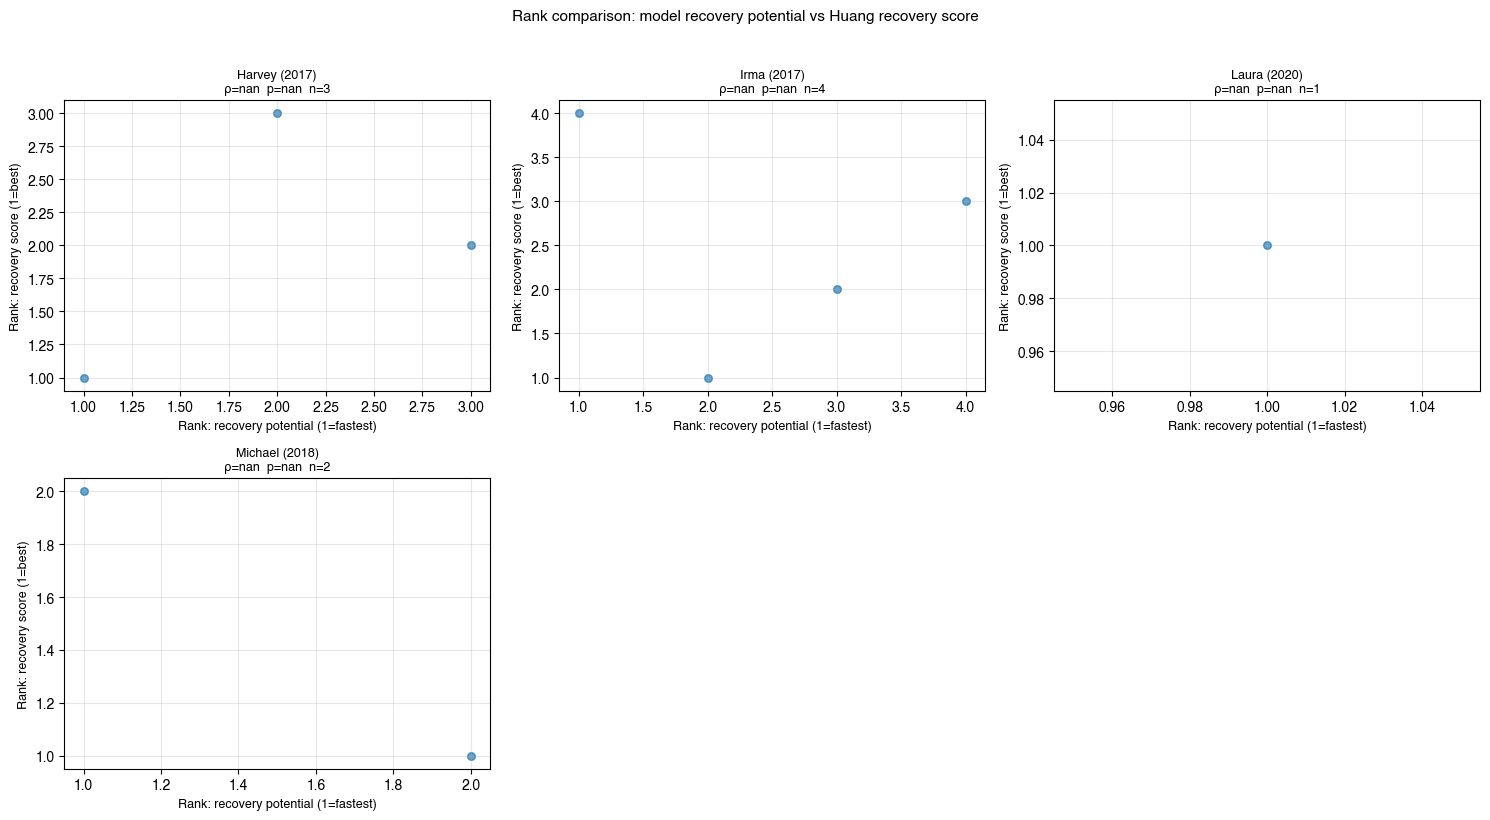

In [23]:
# ---- Rank plots (within each event) ----
n_ev_eval = len(events_eval)
ncols     = min(3, n_ev_eval)
nrows     = (n_ev_eval + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.atleast_1d(axes).ravel()

for idx, aid in enumerate(events_eval):
    ax  = axes[idx]
    sub = eval_df[eval_df['atcf_id'] == aid].copy()
    sub['rank_model']  = sub['recovery_potential_months'].rank()
    sub['rank_obs']    = sub['recovery_score'].rank(ascending=False)  # higher score = faster recovery = lower rank

    ax.scatter(sub['rank_model'], sub['rank_obs'], s=30, alpha=0.7)
    ax.set_xlabel('Rank: recovery potential (1=fastest)', fontsize=9)
    ax.set_ylabel('Rank: recovery score (1=best)', fontsize=9)
    storm_label = STORM_LABEL.get(aid, aid)
    r = spearman_row(aid, sub, 'recovery_potential_months', 'recovery_score')
    ax.set_title(f'{storm_label}\nρ={r["rho"]:.3f}  p={r["p"]:.3f}  n={r["n"]}', fontsize=9)
    ax.grid(True, alpha=0.3)

for ax in axes[n_ev_eval:]:
    ax.set_visible(False)

plt.suptitle('Rank comparison: model recovery potential vs Huang recovery score', fontsize=11, y=1.02)
plt.tight_layout()
out_fp = FIGURES_DIR / 'huang_rank_plots.png'
plt.savefig(out_fp, dpi=150, bbox_inches='tight')
print(f'Saved rank plots → {out_fp}')
plt.show()

## Run summary

In [24]:
print('=' * 65)
print('RUN SUMMARY — historical storm recovery pipeline')
print('=' * 65)

print(f'\n--- Storms ---')
print(f'  Target storms requested : {len(TARGET_ATCF)}')
print(f'  Present in wind field set  : {len(PRESENT_ATCF)}  →  {PRESENT_ATCF}')
print(f'  MISSING from wind field set: {len(MISSING_ATCF)}  →  {MISSING_ATCF}')
print(f'  Wind-only (no Dmat)     : {WIND_ONLY_ATCF}')

print(f'\n--- Windmax match residuals ---')
if not match_report.empty:
    print(f'  County-storm matches : {len(match_report)}')
    print(f'  Mean residual        : {match_report["residual"].mean():.2f} m/s')
    print(f'  Median residual      : {match_report["residual"].median():.2f} m/s')
    print(f'  Max residual         : {match_report["residual"].max():.2f} m/s')
    n_amb = int(match_report['ambiguous'].sum())
    n_tot = len(match_report)
    print(f'  Ambiguous matches    : {n_amb}/{n_tot} ({100*n_amb/n_tot:.1f}%)')
else:
    print('  (no match report available)')

print(f'\n--- Scaling ---')
_sc = np.load(SCALING_NPZ_HIST, allow_pickle=True)
sc_arr = _sc['Scaling']
print(f'  Shape: {sc_arr.shape}')
for e_idx, aid in enumerate(haz_atcf_ids):
    sv    = sc_arr[e_idx, :]
    above = sv[sv > 1.0]
    wof   = ' [WIND-ONLY]' if aid in hist_wind_only else ''
    if above.size > 0:
        print(f'  {aid}: counties with Scaling>1={above.size}, '
              f'mean={above.mean():.2f}, max={above.max():.2f}{wof}')
    else:
        print(f'  {aid}: all Scaling=1.0{wof}')

print(f'\n--- Huang evaluation ---')
print(f'  Comparison storms in Huang: {comparison_atcf}')
if not_available:
    print(f'  Excluded (missing wind fields): {not_available}')
print(f'  County-events after filter (n_changed≥30): {len(eval_df)}')

print(f'\n--- Spearman correlations (pooled, n_changed≥30) ---')
for x_col, y_col, _ in CORR_PAIRS:
    row = results_df[
        (results_df['label'] == 'POOLED') &
        (results_df['x_col'] == x_col) &
        (results_df['y_col'] == y_col)
    ]
    if not row.empty:
        r = row.iloc[0]
        print(f'  {x_col} vs {y_col}: ρ={r["rho"]:.3f}  p={r["p"]:.4f}  n={int(r["n"])}')

print(f'\n--- Per-event Spearman (recovery_potential_months vs recovery_score) ---')
per_ev = results_df[
    (results_df['x_col'] == 'recovery_potential_months') &
    (results_df['y_col'] == 'recovery_score') &
    (results_df['label'] != 'POOLED')
]
print(per_ev[['label', 'n', 'rho', 'p']].to_string(index=False))

print(f'\n--- Per-event Spearman (reconstruction_capacity vs rebuild_rate) ---')
per_ev2 = results_df[
    (results_df['x_col'] == 'reconstruction_capacity') &
    (results_df['y_col'] == 'rebuild_rate') &
    (results_df['label'] != 'POOLED')
]
print(per_ev2[['label', 'n', 'rho', 'p']].to_string(index=False))

print(f'\n--- Output files ---')
print(f'  Hazard HDF5       : {HAZ_HDF5}')
print(f'  Scaling NPZ       : {SCALING_NPZ_HIST}')
print(f'  Impact CSVs       : {IMPACT_DIR_HIST}/per_event/ ({len(list(per_event_dir.glob("*.csv")))} files)')
print(f'  Recovery CSV      : {RECOVERY_CSV}')
print(f'  Figures dir       : {FIGURES_DIR}')
print(f'  Spearman results  : {results_csv}')
print('=' * 65)

RUN SUMMARY — historical storm recovery pipeline

--- Storms ---
  Target storms requested : 10
  Present in wind field set  : 9  →  ['AL142018', 'AL132020', 'AL092017', 'AL112017', 'AL092012', 'AL092016', 'AL122005', 'AL092021', 'AL092022']
  MISSING from wind field set: 1  →  ['AL162017']
  Wind-only (no Dmat)     : ['AL092021', 'AL092022']

--- Windmax match residuals ---
  County-storm matches : 1170
  Mean residual        : 16.27 m/s
  Median residual      : 15.26 m/s
  Max residual         : 65.72 m/s
  Ambiguous matches    : 28/1170 (2.4%)

--- Scaling ---
  Shape: (9, 3220)
  AL142018: counties with Scaling>1=238, mean=1.33, max=2.56
  AL132020: counties with Scaling>1=162, mean=1.33, max=1.70
  AL092017: counties with Scaling>1=121, mean=1.35, max=1.74
  AL112017: counties with Scaling>1=153, mean=1.20, max=2.23
  AL092012: counties with Scaling>1=111, mean=1.29, max=1.61
  AL092016: counties with Scaling>1=217, mean=1.24, max=2.00
  AL122005: counties with Scaling>1=168, mean